# Image Preprocessing

## Import Libraries

In [1]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

## Set Dataset Path

In [2]:
input_folder = "../Clean_Dataset"
output_folder = "../Preprocessed_Dataset"

os.makedirs(output_folder, exist_ok=True)

print("Input :", input_folder)
print("Output:", output_folder)

Input : ../Clean_Dataset
Output: ../Preprocessed_Dataset


## Load Dataset

In [3]:
classes = [
    folder
    for folder in os.listdir(input_folder)
    if os.path.isdir(os.path.join(input_folder, folder))
]

print("Classes:", classes)

images = []

for cls in classes:

    class_path = os.path.join(
        input_folder,
        cls
    )

    files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for file in files:
        images.append((cls, file))

print("Total Images:", len(images))

Classes: ['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']
Total Images: 693


### Select Sample Image

In [4]:
sample_class = random.choice(classes)

sample_folder = os.path.join(
    input_folder,
    sample_class
)

sample_file = random.choice([
    f for f in os.listdir(sample_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

sample_path = os.path.join(
    sample_folder,
    sample_file
)

original = cv2.imread(sample_path)

print("Class:", sample_class)
print("Image:", sample_file)

Class: Missing_hole
Image: 06_missing_hole_05.jpg


## Colour Normalisation

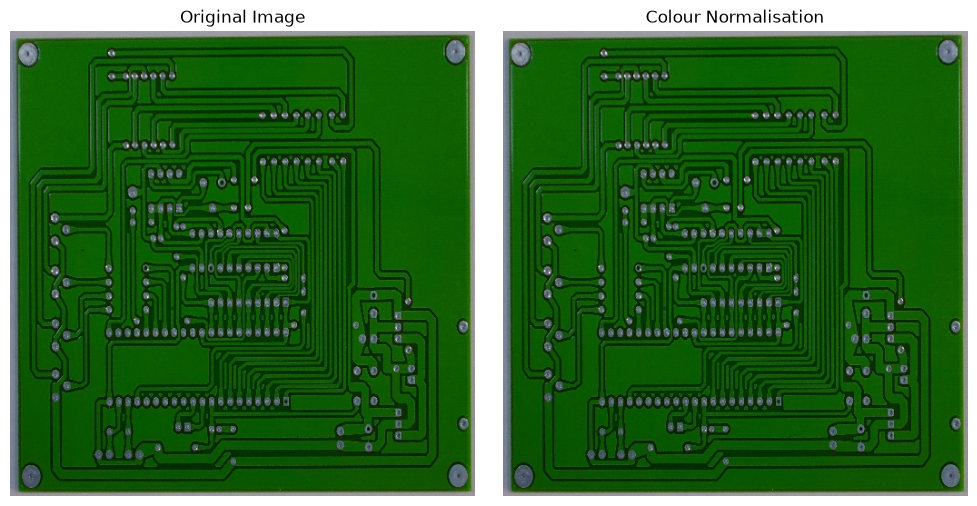

In [32]:
normalised = cv2.normalize(
    original,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

original_rgb = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

normalised_rgb = cv2.cvtColor(
    normalised,
    cv2.COLOR_BGR2RGB
)

plt.figure(
    figsize=(10, 5)
)

plt.subplot(
    1, 2, 1
)

plt.imshow(
    original_rgb
)

plt.title(
    "Original Image"
)

plt.axis("off")


plt.subplot(
    1, 2, 2
)

plt.imshow(
    normalised_rgb
)

plt.title(
    "Colour Normalisation"
)

plt.axis("off")

plt.tight_layout()

plt.show()

## Gaussian Filter

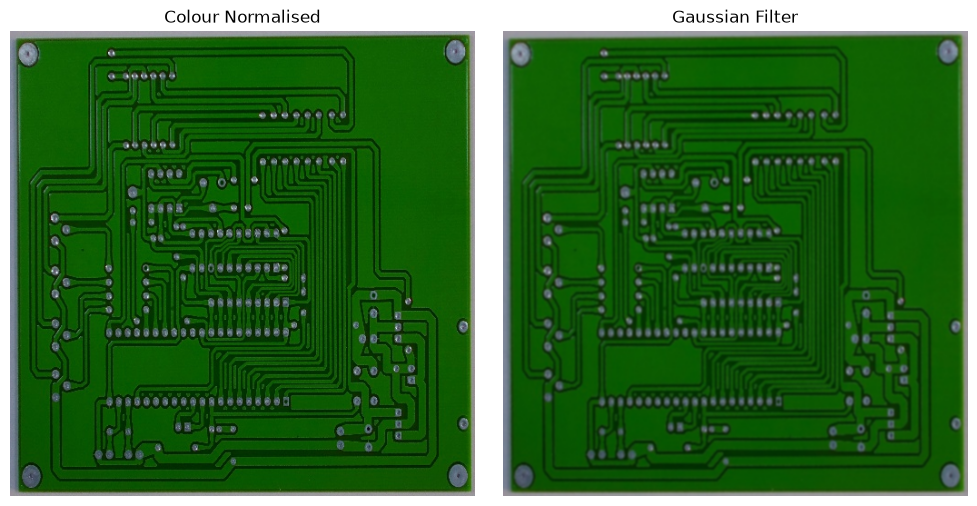

In [33]:
gaussian = cv2.GaussianBlur(
    normalised,
    (5, 5),
    0
)

gaussian_rgb = cv2.cvtColor(
    gaussian,
    cv2.COLOR_BGR2RGB
)

plt.figure(
    figsize=(10, 5)
)

plt.subplot(
    1, 2, 1
)

plt.imshow(
    normalised_rgb
)

plt.title(
    "Colour Normalised"
)

plt.axis("off")


plt.subplot(
    1, 2, 2
)

plt.imshow(
    gaussian_rgb
)

plt.title(
    "Gaussian Filter"
)

plt.axis("off")

plt.tight_layout()

plt.show()

## Gaussian Filter Kernel Matrix


In [34]:
# Original 5 × 5 Gaussian Kernel

gaussian_kernel_raw = np.array([
    [1,  4,  7,  4,  1],
    [4, 16, 26, 16,  4],
    [7, 26, 41, 26,  7],
    [4, 16, 26, 16,  4],
    [1,  4,  7,  4,  1]
], dtype=np.float32)


# Normalise the kernel

gaussian_kernel = (
    gaussian_kernel_raw /
    gaussian_kernel_raw.sum()
)


print("Original 5 × 5 Gaussian Kernel:")
print(gaussian_kernel_raw)

print(
    "\nNormalised 5 × 5 Gaussian Kernel:"
)

print(
    gaussian_kernel
)

Original 5 × 5 Gaussian Kernel:
[[ 1.  4.  7.  4.  1.]
 [ 4. 16. 26. 16.  4.]
 [ 7. 26. 41. 26.  7.]
 [ 4. 16. 26. 16.  4.]
 [ 1.  4.  7.  4.  1.]]

Normalised 5 × 5 Gaussian Kernel:
[[0.003663   0.01465201 0.02564103 0.01465201 0.003663  ]
 [0.01465201 0.05860806 0.0952381  0.05860806 0.01465201]
 [0.02564103 0.0952381  0.15018316 0.0952381  0.02564103]
 [0.01465201 0.05860806 0.0952381  0.05860806 0.01465201]
 [0.003663   0.01465201 0.02564103 0.01465201 0.003663  ]]


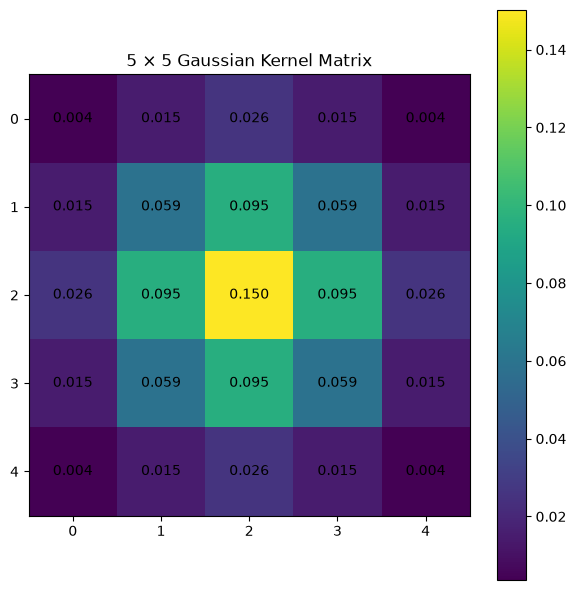

In [35]:
plt.figure(
    figsize=(6, 6)
)

plt.imshow(
    gaussian_kernel
)

plt.colorbar()

plt.title(
    "5 × 5 Gaussian Kernel Matrix"
)

for i in range(5):

    for j in range(5):

        plt.text(
            j,
            i,
            f"{gaussian_kernel[i, j]:.3f}",
            ha="center",
            va="center"
        )

plt.xticks(
    range(5)
)

plt.yticks(
    range(5)
)

plt.tight_layout()

plt.show()

## Gaussian Kernel Application

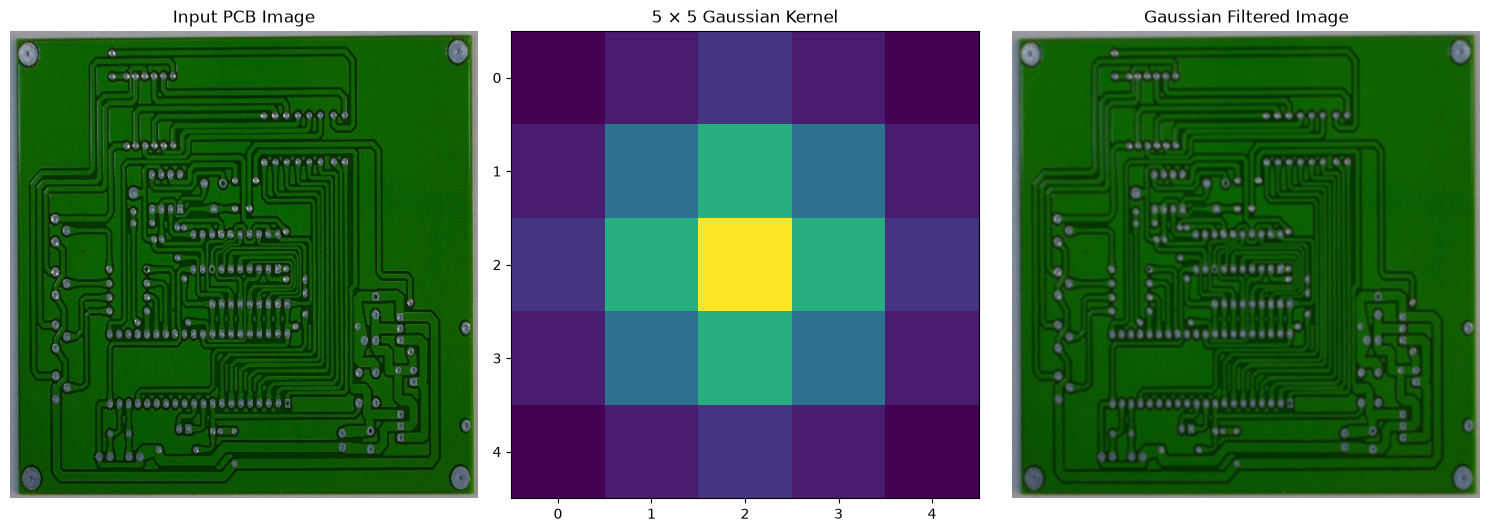

In [38]:
plt.figure(
    figsize=(15, 5)
)

# Input PCB

plt.subplot(
    1, 3, 1
)

plt.imshow(
    normalised_rgb
)

plt.title(
    "Input PCB Image"
)

plt.axis("off")


# Gaussian Kernel

plt.subplot(
    1, 3, 2
)

plt.imshow(
    gaussian_kernel
)

plt.title(
    "5 × 5 Gaussian Kernel"
)

plt.xticks(
    range(5)
)

plt.yticks(
    range(5)
)


# Filtered Image

plt.subplot(
    1, 3, 3
)

plt.imshow(
    gaussian_rgb
)

plt.title(
    "Gaussian Filtered Image"
)

plt.axis("off")


plt.tight_layout()

plt.show()

## CLAHE Demonstration

L Channel: (512, 512)
A Channel: (512, 512)
B Channel: (512, 512)
L Channel: (512, 512)
A Channel: (512, 512)
B Channel: (512, 512)


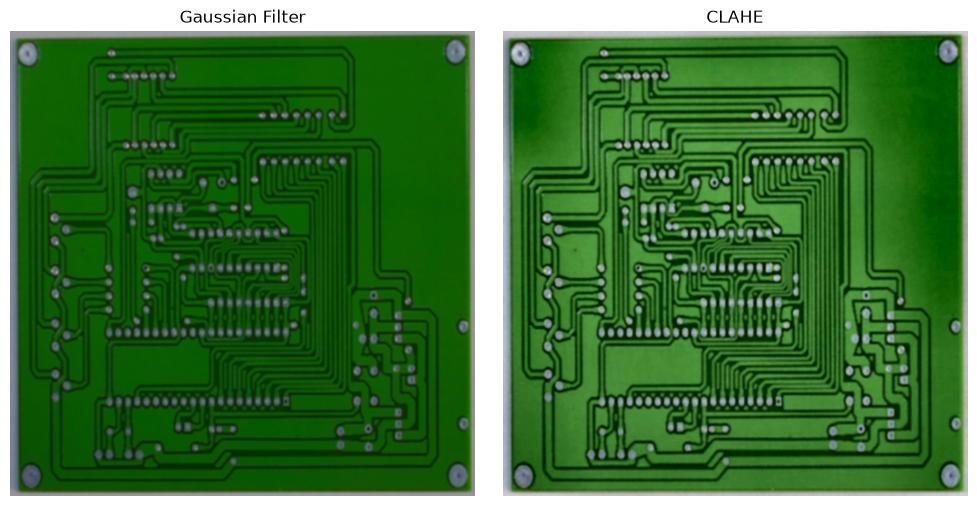

In [44]:
lab = cv2.cvtColor(
    gaussian,
    cv2.COLOR_BGR2LAB
)

l, a, b = cv2.split(
    lab
)

print(
    "L Channel:",
    l.shape
)

print(
    "A Channel:",
    a.shape
)

print(
    "B Channel:",
    b.shape
)

l, a, b = cv2.split(lab)

print("L Channel:", l.shape)
print("A Channel:", a.shape)
print("B Channel:", b.shape)

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

l_clahe = clahe.apply(
    l
)

lab_clahe = cv2.merge(
    (
        l_clahe,
        a,
        b
    )
)

processed = cv2.cvtColor(
    lab_clahe,
    cv2.COLOR_LAB2BGR
)

processed_rgb = cv2.cvtColor(
    processed,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gaussian_rgb)
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed_rgb)
plt.title("CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

## CLAHE 8 × 8 Tile Grid

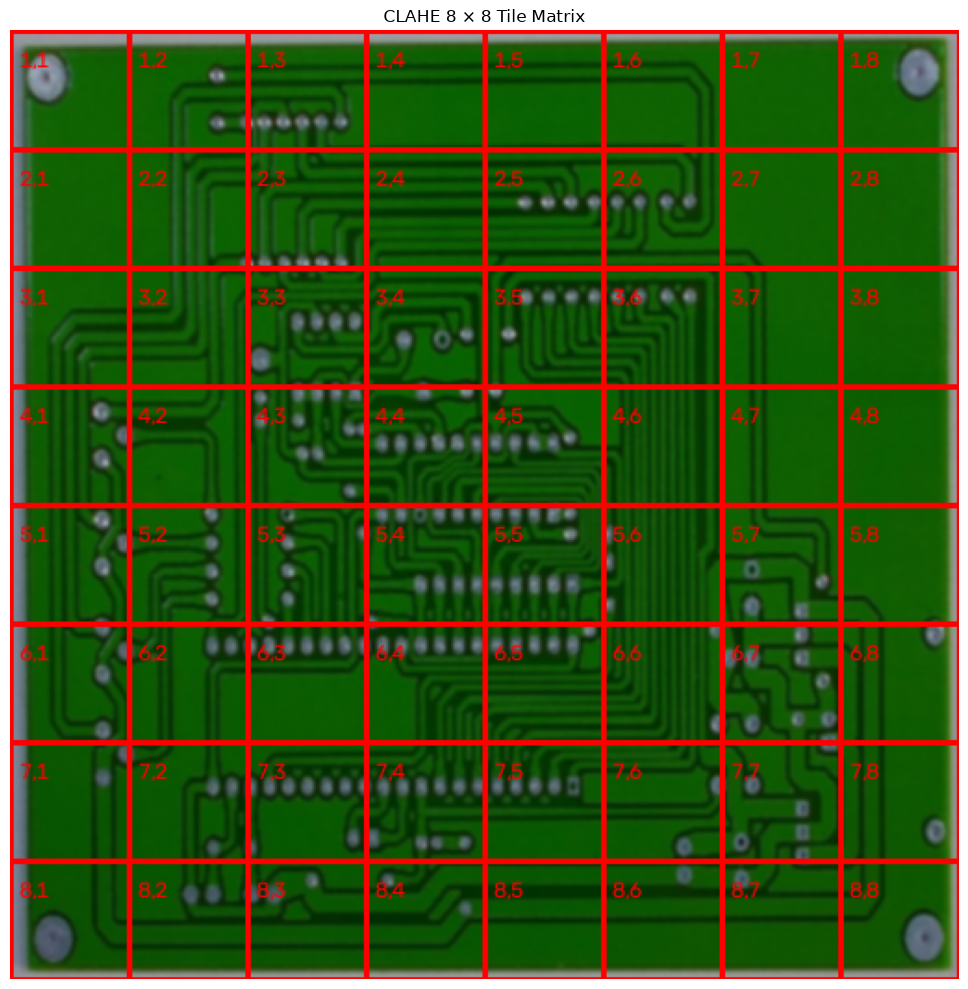

In [45]:
# Create a copy of the Gaussian-filtered image

clahe_grid_image = gaussian.copy()


# Convert BGR to RGB

clahe_grid_image = cv2.cvtColor(
    clahe_grid_image,
    cv2.COLOR_BGR2RGB
)


# Get image dimensions

height, width = (
    clahe_grid_image.shape[:2]
)


# Draw 8 × 8 tile grid

for row in range(8):

    for col in range(8):

        x1 = int(
            width * col / 8
        )

        y1 = int(
            height * row / 8
        )

        x2 = int(
            width * (col + 1) / 8
        )

        y2 = int(
            height * (row + 1) / 8
        )


        # Draw tile boundary

        cv2.rectangle(
            clahe_grid_image,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            2
        )


        # Tile number

        cv2.putText(
            clahe_grid_image,
            f"{row + 1},{col + 1}",
            (x1 + 5, y1 + 20),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4,
            (255, 0, 0),
            1
        )


plt.figure(
    figsize=(10, 10)
)

plt.imshow(
    clahe_grid_image
)

plt.title(
    "CLAHE 8 × 8 Tile Matrix"
)

plt.axis("off")

plt.tight_layout()

plt.show()

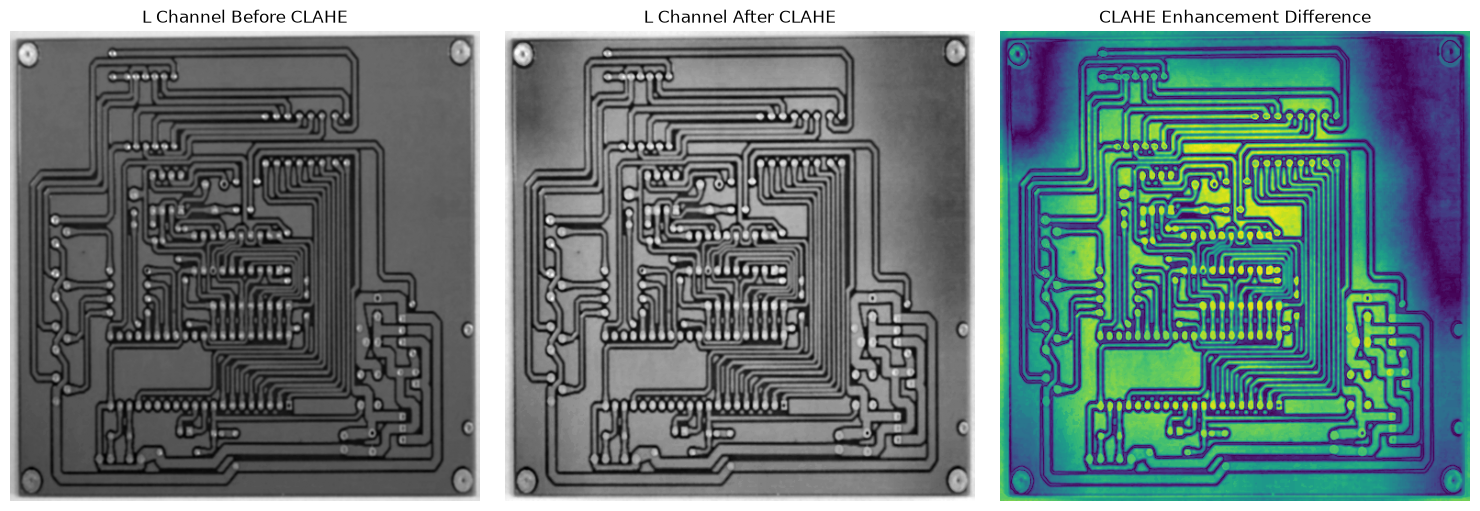

In [46]:
## CLAHE L Channel Comparison

plt.figure(figsize=(15, 5))

# Original L Channel
plt.subplot(1, 3, 1)

plt.imshow(
    l,
    cmap="gray"
)

plt.title(
    "L Channel Before CLAHE"
)

plt.axis("off")


# CLAHE L Channel
plt.subplot(1, 3, 2)

plt.imshow(
    l_clahe,
    cmap="gray"
)

plt.title(
    "L Channel After CLAHE"
)

plt.axis("off")


# Difference
difference = cv2.absdiff(
    l_clahe,
    l
)

plt.subplot(1, 3, 3)

plt.imshow(
    difference,
)

plt.title(
    "CLAHE Enhancement Difference"
)

plt.axis("off")

plt.tight_layout()

plt.show()

### Full Processing Pipeline

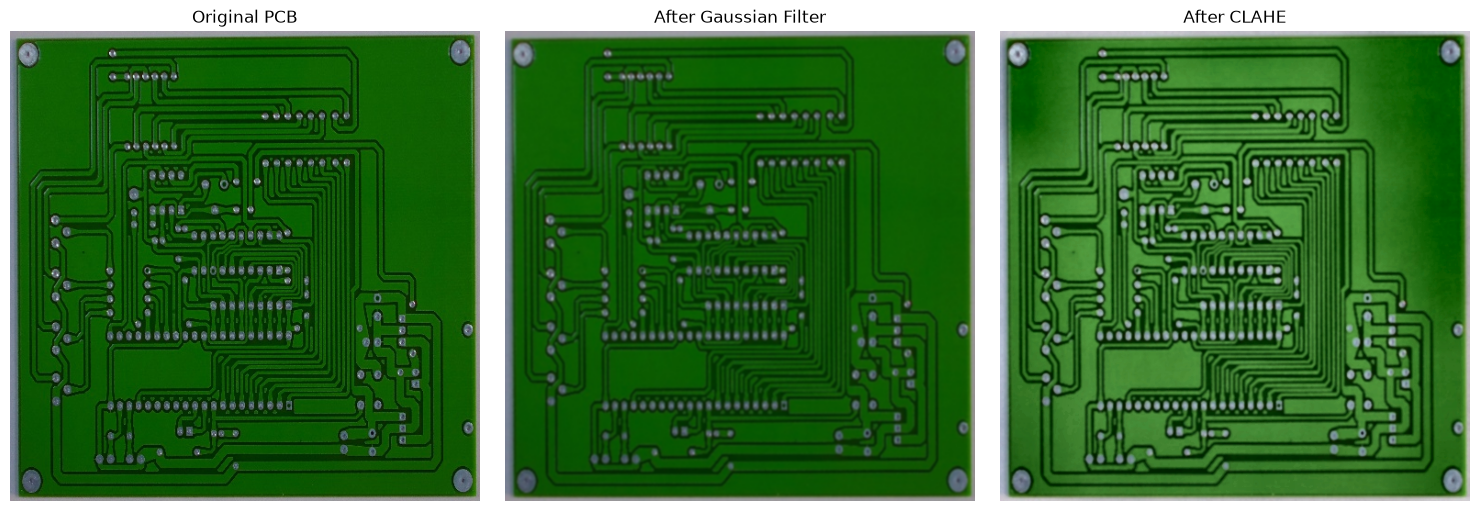

In [47]:
plt.figure(
    figsize=(15, 5)
)


# Original

plt.subplot(
    1, 3, 1
)

plt.imshow(
    original_rgb
)

plt.title(
    "Original PCB"
)

plt.axis("off")


# Gaussian

plt.subplot(
    1, 3, 2
)

plt.imshow(
    gaussian_rgb
)

plt.title(
    "After Gaussian Filter"
)

plt.axis("off")


# CLAHE

plt.subplot(
    1, 3, 3
)

plt.imshow(
    processed_rgb
)

plt.title(
    "After CLAHE"
)

plt.axis("off")


plt.tight_layout()

plt.show()

## Image Preprocessing

In [48]:
processed_images = 0
skipped_images = 0

for cls, file in images:

    img_path = os.path.join(
        input_folder,
        cls,
        file
    )

    img = cv2.imread(img_path)

    if img is None:
        skipped_images += 1
        continue

    # Colour Normalisation
    img = cv2.normalize(
        img,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    # Gaussian Filter
    gaussian = cv2.GaussianBlur(
        img,
        (5, 5),
        0
    )

    # Convert BGR to LAB
    lab = cv2.cvtColor(
        gaussian,
        cv2.COLOR_BGR2LAB
    )

    # Split LAB channels
    l, a, b = cv2.split(lab)

    # CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)

    # Merge LAB channels
    lab = cv2.merge(
        (l, a, b)
    )

    # Convert LAB back to BGR
    processed = cv2.cvtColor(
        lab,
        cv2.COLOR_LAB2BGR
    )

    # Create output folder
    save_folder = os.path.join(
        output_folder,
        cls
    )

    os.makedirs(
        save_folder,
        exist_ok=True
    )

    # Save processed image
    save_path = os.path.join(
        save_folder,
        file
    )

    cv2.imwrite(
        save_path,
        processed
    )

    processed_images += 1

print("Image Preprocessing Completed!")

Image Preprocessing Completed!


## Display Before & After

Original Path:
../Clean_Dataset\Missing_hole\06_missing_hole_05.jpg

Processed Path:
../Preprocessed_Dataset\Missing_hole\06_missing_hole_05.jpg

Image Exists: True


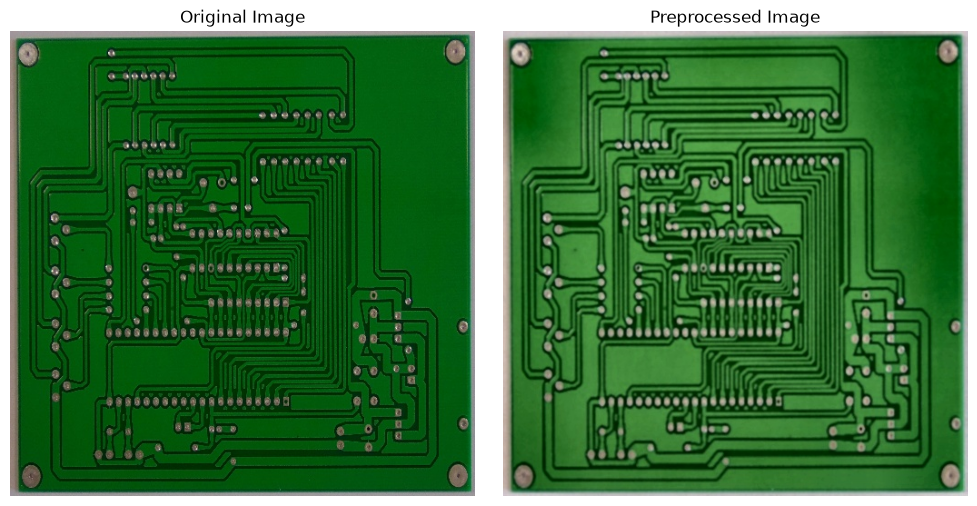

In [49]:
processed_path = os.path.join(
    output_folder,
    sample_class,
    sample_file
)

print("Original Path:")
print(sample_path)

print("\nProcessed Path:")
print(processed_path)

print(
    "\nImage Exists:",
    os.path.exists(processed_path)
)

original = cv2.imread(sample_path)

processed = cv2.imread(processed_path)

original = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

processed = cv2.cvtColor(
    processed,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed)
plt.title("Preprocessed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

## Histogram Demonstration

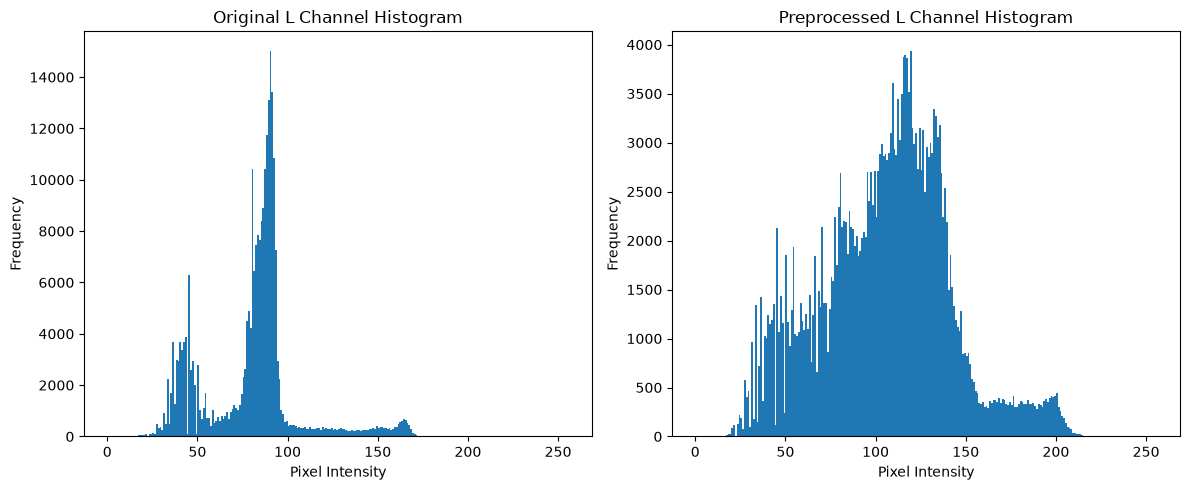

In [50]:
original_bgr = cv2.imread(sample_path)
processed_bgr = cv2.imread(processed_path)

original_lab = cv2.cvtColor(
    original_bgr,
    cv2.COLOR_BGR2LAB
)

processed_lab = cv2.cvtColor(
    processed_bgr,
    cv2.COLOR_BGR2LAB
)

original_l, _, _ = cv2.split(original_lab)
processed_l, _, _ = cv2.split(processed_lab)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.hist(
    original_l.ravel(),
    bins=256,
    range=(0, 256)
)

plt.title("Original L Channel Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)

plt.hist(
    processed_l.ravel(),
    bins=256,
    range=(0, 256)
)

plt.title("Preprocessed L Channel Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Summary

In [51]:
print("========== Preprocessed Dataset Summary ==========")

processed_images = 0

for cls in classes:

    folder = os.path.join(
        output_folder,
        cls
    )

    if not os.path.exists(folder):
        print(f"{cls}: 0")
        continue

    count = len([
        f for f in os.listdir(folder)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ])

    processed_images += count

    print(f"{cls}: {count}")

print("-------------------------------------")
print("Total Images     :", len(images))
print("Processed Images :", processed_images)
print("Skipped Images   :", skipped_images)

========== Preprocessed Dataset Summary ==========
Missing_hole: 115
Mouse_bite: 115
Open_circuit: 116
Short: 116
Spur: 115
Spurious_copper: 116
-------------------------------------
Total Images     : 693
Processed Images : 693
Skipped Images   : 0
